#### Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

#### Load Datasets

In [3]:
books = pd.read_csv("Books.csv", encoding="ISO-8859-1" , low_memory=False)
ratings = pd.read_csv("Ratings.csv", encoding="ISO-8859-1")
users = pd.read_csv("Users.csv", encoding="ISO-8859-1")

##### Note:- We used encoding="ISO-8859-1" because the dataset contains special characters (like accents in book titles and author names) that cannot be read properly using the default UTF-8 encoding. Specifying the encoding ensures the file loads without errors. low_memory=False is added to allow pandas to read the file in one go and avoid data type warnings caused by mixed values in some columns.

##### Check Dataset Structure

In [4]:
books.info()
ratings.info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), obje

#### Note :- This step helps us understand column names, data types, and missing values before starting the cleaning process.

#### Check Missing Values

In [5]:
books.isnull().sum()
ratings.isnull().sum()
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

##### Note :- We identify how many null values exist in each column so that we can decide the appropriate cleaning method.

#### Remove Duplicate Rows

In [6]:
books.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)
users.drop_duplicates(inplace=True)

##### Note :- Duplicate records are removed to ensure data quality and prevent incorrect analysis later.

#### Fill Missing Age Values

In [7]:
users['Age'] = users['Age'].fillna(users['Age'].median())

##### Note :- Missing age values are replaced using the median age because it is less affected by extreme values and keeps the data realistic.

#### Verify Missing Values After Filling

In [8]:
users.isnull().sum()

User-ID     0
Location    0
Age         0
dtype: int64

##### Note :- This confirms that all missing values in the Age column have been successfully handled.

#### Remove Rows with Missing Book Details

In [9]:
books.dropna(inplace=True)

##### Note :- Rows with missing author, publisher, or image information are removed to maintain consistent book data.

#### Verify Books Dataset

In [10]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64

In [11]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64

##### Note :- Ensures that no null values remain in the books dataset after cleaning.

#### Check Ratings Dataset

In [12]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

##### Note :- This confirms that the ratings dataset does not contain missing values.

#### Check Unique Rating Values

In [13]:
ratings['Book-Rating'].unique()

array([ 0,  5,  3,  6,  8,  7, 10,  9,  4,  1,  2])

##### Note :- We check all unique rating values to ensure ratings fall within the expected range.

#### Statistical Summary of Users Data

In [14]:
users.describe()

,User-ID,Age
count,278858.00000,278858.000000
mean,139429.50000,33.658568
std,80499.51502,11.282618
min,1.00000,0.000000
25%,69715.25000,29.000000
50%,139429.50000,32.000000
75%,209143.75000,35.000000
max,278858.00000,244.000000


##### Note :- Provides statistical insights such as mean, minimum, and maximum values to detect unrealistic ages.

#### Filter Unrealistic Age Values

In [15]:
users = users[(users['Age'] >= 5) & (users['Age'] <= 90)]

##### Note :- Users with unrealistic ages are removed to improve data reliability.

#### Verify Age Range

In [16]:
users.describe()

,User-ID,Age
count,277546.000000,277546.000000
mean,139430.331181,33.636821
std,80493.636906,10.615707
min,1.000000,5.000000
25%,69715.250000,29.000000
50%,139424.500000,32.000000
75%,209134.750000,35.000000
max,278858.000000,90.000000


#### Save Cleaned Datasets

In [17]:
books.to_csv("clean_books.csv", index=False)

In [18]:
ratings.to_csv("clean_ratings.csv", index=False)

In [19]:
users.to_csv("clean_users.csv", index=False)

#### Final Dataset Shape Check

In [20]:
print(books.shape)
print(ratings.shape)
print(users.shape)

(271353, 8)
(1149780, 3)
(277546, 3)


##### Note :- This displays the number of rows and columns after cleaning to verify that the datasets are correctly processed.

### Load cleaned datasets

We now load the cleaned files so that our analysis is based on trusted and validated data. This helps us avoid repeating cleaning work and ensures that insights and model decisions are reliable.


In [3]:
books = pd.read_csv("clean_books.csv")
ratings = pd.read_csv("clean_ratings.csv")
users = pd.read_csv("clean_users.csv")

print(books.shape, ratings.shape, users.shape)

(271353, 8) (1149780, 3) (277546, 3)


### Preview datasets

We take a quick look at the first rows to refresh our understanding of columns and values. This helps us mentally map what information is available for feature creation.


In [4]:
display(books.head())
display(ratings.head())
display(users.head())

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


,User-ID,Location,Age
0,1,"nyc, new york, usa",32.0
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",32.0
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",32.0


### Merge datasets

We combine users books and ratings into one master table. This allows us to analyze behavior preferences and popularity in a single place which is necessary for recommendations.


In [5]:
data = ratings.merge(books, on="ISBN", how="left") \
              .merge(users, on="User-ID", how="left")

print(data.shape)
data.head()

(1149780, 12)


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",32.0
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001.0,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa",32.0
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996.0,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia",16.0
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999.0,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia",16.0
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001.0,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia",16.0


In [6]:
data.to_csv("books_data.csv", index=False)

### Why we merge datasets

We merge users books and ratings so we can study behavior preferences and popularity together. Keeping everything in one table makes analysis and later modeling easier for us.

### Load visualization tools

We load plotting libraries to explore distributions trends and patterns visually. Visual signals help us detect bias popularity and anomalies quickly.


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Ratings distribution

We study how users rate books. This helps us understand whether people are generous strict or neutral which impacts recommendation logic.


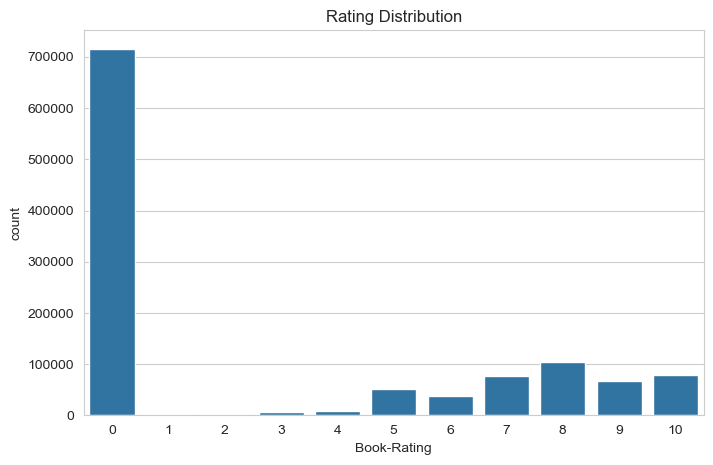

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x="Book-Rating", data=ratings)
plt.title("Rating Distribution")
plt.show()

### Explicit and implicit ratings

We separate zero ratings from real scores. This helps us understand user intent and choose correct modeling strategies later.


In [26]:
implicit = (ratings["Book-Rating"] == 0).sum()
explicit = (ratings["Book-Rating"] != 0).sum()

print("Implicit:", implicit)
print("Explicit:", explicit)

Implicit: 716109
Explicit: 433671


### Visual view of rating types

We visualize explicit and implicit signals to understand how much real preference data we have versus passive interactions.


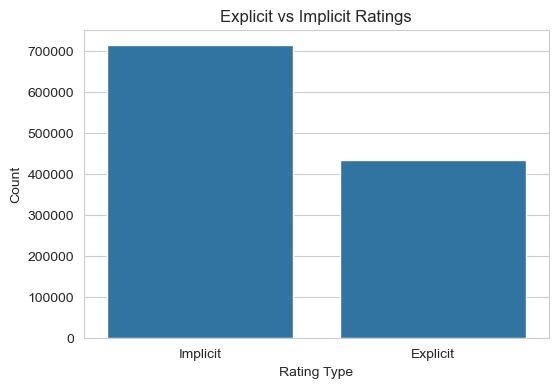

In [43]:
rating_type = ratings["Book-Rating"].apply(lambda x: "Implicit" if x == 0 else "Explicit")

plt.figure(figsize=(6,4))
sns.countplot(x=rating_type)
plt.title("Explicit vs Implicit Ratings")
plt.xlabel("Rating Type")
plt.ylabel("Count")
plt.show()

### User activity level

We measure how many ratings each user gives. This helps us detect highly active readers and cold start users.

In [28]:
user_activity = ratings.groupby("User-ID")["Book-Rating"].count()
user_activity.describe()

count    105283.000000
mean         10.920851
std          90.562825
min           1.000000
25%           1.000000
50%           1.000000
75%           4.000000
max       13602.000000
Name: Book-Rating, dtype: float64

### Book popularity

We count how many times each book is rated. Frequently rated books form a strong baseline for popularity based recommendations.


In [29]:
book_popularity = ratings.groupby("ISBN")["Book-Rating"].count() \
                         .sort_values(ascending=False)

book_popularity.head(10)

ISBN
0971880107    2502
0316666343    1295
0385504209     883
0060928336     732
0312195516     723
044023722X     647
0679781587     639
0142001740     615
067976402X     614
0671027360     586
Name: Book-Rating, dtype: int64

### Most rated book titles

We translate ISBN into titles to identify which books attract the most attention from readers.


In [30]:
most_rated_titles = data.groupby("Book-Title")["Book-Rating"] \
                         .count() \
                         .sort_values(ascending=False)

most_rated_titles.head(10)

Book-Title
Wild Animus                                        2502
The Lovely Bones: A Novel                          1295
The Da Vinci Code                                   898
A Painted House                                     838
The Nanny Diaries: A Novel                          828
Bridget Jones's Diary                               815
The Secret Life of Bees                             774
Divine Secrets of the Ya-Ya Sisterhood: A Novel     740
The Red Tent (Bestselling Backlist)                 723
Angels &amp; Demons                                 670
Name: Book-Rating, dtype: int64

### Average rating per book

We compute mean ratings to discover quality perception. Later we can combine this with popularity for balanced recommendations.


In [31]:
avg_rating = data.groupby("Book-Title")["Book-Rating"] \
                 .mean() \
                 .sort_values(ascending=False)

avg_rating.head(10)

Book-Title
Film Is: The International Free Cinema                                                           10.0
Cladistics: A Practical Course in Systematics (Systematics Association Publications, Vol. 10)    10.0
Jo's Boys : From the Original Publisher                                                          10.0
The Vanished Priestess : An Annie Szabo Mystery                                                  10.0
Game and Hunting                                                                                 10.0
Joan Miro: 1893-1983 (Basic Series)                                                              10.0
The Vampire's Apprentice                                                                         10.0
The Vampire in Lore and Legend (Dover Books on Anthropology and Folklore)                        10.0
The Vampire in Literature: A Critical Bibliography (Studies in Speculative Fiction, No 21)       10.0
Something Unpredictable: A Novel                                       

### Filter reliable books

We keep books with enough ratings so that high averages are trustworthy and not based on very small samples.


In [32]:
rating_count = data.groupby("Book-Title")["Book-Rating"].count()

reliable_books = rating_count[rating_count >= 50].index

data[data["Book-Title"].isin(reliable_books)] \
    .groupby("Book-Title")["Book-Rating"] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

Book-Title
Free                                                     8.017857
The Stand (The Complete and Uncut Edition)               6.175439
Griffin &amp; Sabine: An Extraordinary Correspondence    6.041667
Harry Potter and the Prisoner of Azkaban (Book 3)        5.852804
Harry Potter and the Goblet of Fire (Book 4)             5.824289
The Little Prince                                        5.815603
The Cat in the Hat                                       5.754717
Harry Potter and the Sorcerer's Stone (Book 1)           5.737410
The Hobbit                                               5.700000
Harry Potter and the Order of the Phoenix (Book 5)       5.501441
Name: Book-Rating, dtype: float64

### Author popularity

We evaluate which authors receive maximum engagement. Many readers follow authors so this is useful for personalization.


In [33]:
data.groupby("Book-Author")["Book-Rating"] \
    .count() \
    .sort_values(ascending=False) \
    .head(10)

Book-Author
Stephen King          10053
Nora Roberts           8429
John Grisham           6010
James Patterson        5845
Mary Higgins Clark     4777
Dean R. Koontz         4313
Tom Clancy             4036
Danielle Steel         3726
Sue Grafton            3457
Janet Evanovich        3350
Name: Book-Rating, dtype: int64

### Age distribution

We observe reader age spread to understand our audience. Different age groups usually prefer different genres.


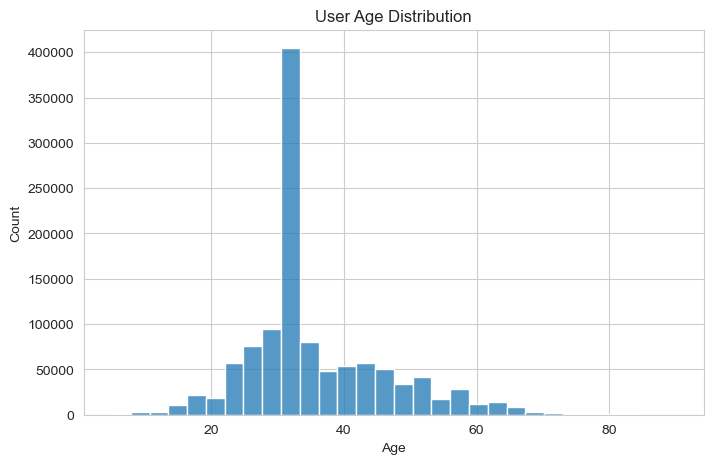

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(data["Age"].dropna(), bins=30)
plt.title("User Age Distribution")
plt.show()

### Extract country

We derive country from location to identify regional trends which can improve localized recommendations.


In [35]:
data["Country"] = data["Location"].astype(str).apply(lambda x: x.split(",")[-1].strip())

data["Country"].value_counts().head(10)

Country
usa               764556
canada            103526
united kingdom     50438
germany            39122
                   27479
spain              25388
australia          25210
france             13862
n/a                13639
italy              12112
Name: count, dtype: int64

### Ratings by country

We check where activity is highest. Regions with more interactions provide stronger learning signals.


In [36]:
data.groupby("Country")["Book-Rating"] \
    .count() \
    .sort_values(ascending=False) \
    .head(10)

Country
usa               764556
canada            103526
united kingdom     50438
germany            39122
                   27479
spain              25388
australia          25210
france             13862
n/a                13639
italy              12112
Name: Book-Rating, dtype: int64

### Matrix sparsity

We measure how empty the user item space is. This helps us decide whether collaborative filtering will be challenging.


In [37]:
n_users = ratings["User-ID"].nunique()
n_books = ratings["ISBN"].nunique()

sparsity = 1 - (len(ratings) / (n_users * n_books))
sparsity

0.9999679322889055

### Visualize user engagement

We plot how many books each user has rated. This helps us immediately see whether most users are active or whether the dataset is dominated by light users.

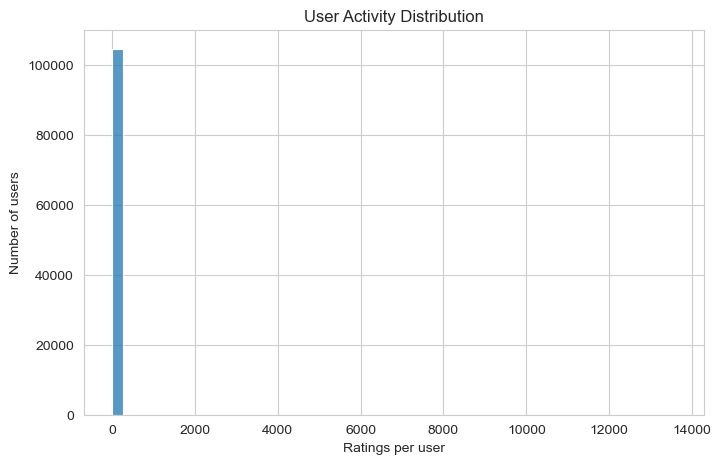

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(user_activity, bins=50)
plt.xlabel("Ratings per user")
plt.ylabel("Number of users")
plt.title("User Activity Distribution")
plt.show()

### Focus on typical behavior

We zoom into normal users by limiting extreme values. Without this step super users hide the real distribution.

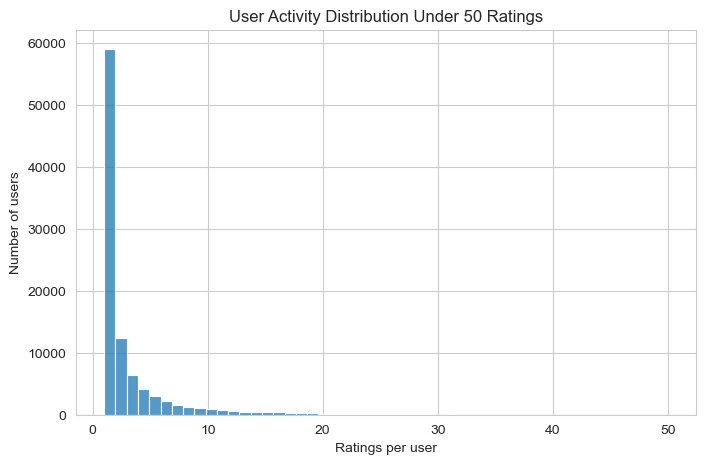

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(user_activity[user_activity <= 50], bins=50)
plt.xlabel("Ratings per user")
plt.ylabel("Number of users")
plt.title("User Activity Distribution Under 50 Ratings")
plt.show()

We use a minimum of 50 ratings so that averages are dependable. Very small samples can produce misleading high scores and harm recommendation quality.

### Identify power users

We inspect the most active readers. A small group can dominate training and bias recommendations.

In [40]:
user_activity.sort_values(ascending=False).head(10)

User-ID
11676     13602
198711     7550
153662     6109
98391      5891
35859      5850
212898     4785
278418     4533
76352      3367
110973     3100
235105     3067
Name: Book-Rating, dtype: int64

### Contribution concentration

We measure how much activity comes from top users. This shows whether engagement is evenly spread or highly concentrated.

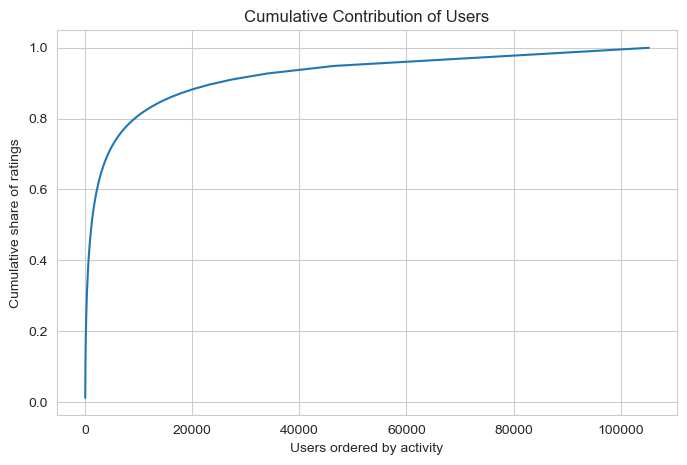

In [41]:
sorted_activity = user_activity.sort_values(ascending=False).values
cumu_percent = sorted_activity.cumsum() / sorted_activity.sum()

plt.figure(figsize=(8,5))
plt.plot(cumu_percent)
plt.xlabel("Users ordered by activity")
plt.ylabel("Cumulative share of ratings")
plt.title("Cumulative Contribution of Users")
plt.show()

### Single interaction users

We compute how many users rated only one book. These users provide very little collaborative signal.

In [44]:
single_users = (user_activity == 1).sum()
total_users = user_activity.shape[0]

print("Percentage:", round(single_users / total_users * 100, 2),"%")

Percentage: 56.2 %


### Key findings from exploration

We found that user activity is highly uneven with many single interaction users and few heavy contributors. The interaction matrix is sparse which may limit neighborhood methods. Therefore we should consider threshold filtering or factorization techniques for robust recommendations.